In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel
import warnings

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
warnings.filterwarnings('ignore')

In [3]:
try:
    import goodpoints.kt as kt
    HAS_GOODPOINTS = True
    print("Successfully loaded 'goodpoints'.")
except ImportError:
    HAS_GOODPOINTS = False
    print("WARNING: 'goodpoints' library is missing.")

In [4]:
# ==========================================
# CELL 2: Data Loading (E-commerce Offers Proxy)
# ==========================================
print("Generating E-commerce Offers dataset with temporal structure...")

np.random.seed(42)
n_samples = 20000

# Generate features typical for an e-commerce scenario
user_age = np.random.normal(35, 10, n_samples)
past_purchases = np.random.poisson(3, n_samples)
time_on_site = np.random.exponential(5, n_samples)
discount_offered = np.random.uniform(5, 50, n_samples)
periods = np.repeat(np.arange(1, 13), np.ceil(n_samples/12))[:n_samples]

y = np.zeros(n_samples)

# Inject Concept Drift: 
# In periods 1-6 (H1), 'discount_offered' primarily drives the click probability.
# In periods 7-12 (H2), 'past_purchases' (loyalty) primarily drives the click probability.
for i in range(n_samples):
    if periods[i] <= 6:
        prob = 1 / (1 + np.exp(-(discount_offered[i] * 0.2 - 5))) 
    else:
        prob = 1 / (1 + np.exp(-(past_purchases[i] * 0.8 - 2)))
    y[i] = np.random.binomial(1, prob)

df = pd.DataFrame({
    'user_age': user_age,
    'past_purchases': past_purchases,
    'time_on_site': time_on_site,
    'discount_offered': discount_offered,
    'period': periods
})

# TabReD-style temporal split: Train on historical data, Validate on future data
train_mask = df['period'] <= 8
X_train = df[train_mask].drop(columns=['period'])
y_train = y[train_mask]

X_val = df[~train_mask].drop(columns=['period'])
y_val = y[~train_mask]

features = X_train.columns.tolist()

print(f"Data ready. Train size: {len(X_train)} | Validation size: {len(X_val)}")

Generating E-commerce Offers dataset with temporal structure...
Data ready. Train size: 13336 | Validation size: 6664


In [5]:
# ==========================================
# CELL 3: Baseline Model Training
# ==========================================
print("Training the XGBoost Classifier...")

model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1, 
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

print(f"Training complete. Train AUC: {train_auc:.3f} | Validation AUC: {val_auc:.3f}")

Training the XGBoost Classifier...
Training complete. Train AUC: 0.852 | Validation AUC: 0.581


In [6]:
# ==========================================
# CELL 4: Compress Then Explain (CTE) Core
# ==========================================

def smart_rbf_kernel(X, Y):
    """
    RBF kernel wrapper compatible with the goodpoints library.
    
    Handles an internal edge case where evaluating the kernel on the exact same 
    matrix (X vs X) requires a 1D array of diagonal values instead of a full 
    2D matrix to prevent broadcasting errors.
    """
    X2d = np.atleast_2d(X)
    Y2d = np.atleast_2d(Y)

    # Handle the identical-object edge case: RBF diagonal k(x,x) is always 1.0
    if (X2d.ndim == 2
            and Y2d.ndim == 2
            and X2d.shape == Y2d.shape
            and X2d.shape[0] > 1
            and np.shares_memory(X, Y)):
        return np.ones(X2d.shape[0])

    # Standard evaluation (point vs. set or set vs. set)
    K = rbf_kernel(X2d, Y2d)

    if K.shape[0] == 1 or K.shape[1] == 1:
        return K.flatten()

    return K


def get_cte_background(X_data, target_size=50):
    """
    Generates a representative background dataset for SHAP using Kernel Thinning (CTE).
    """
    if not HAS_GOODPOINTS:
        return shap.sample(X_data, target_size)

    X_clean = X_data.copy().reset_index(drop=True)
    m_steps = int(np.floor(np.log2(len(X_clean) / target_size)))
    m_steps = min(m_steps, 6)

    if m_steps <= 0:
        return X_clean.sample(min(target_size, len(X_clean)), random_state=42)

    X_np = np.ascontiguousarray(X_clean.values.astype(np.float64))
    n_out = len(X_np) // (2 ** m_steps)
    print(f"  -> KT: {len(X_clean)} input points, {m_steps} steps -> ~{n_out} coreset points")

    compressed_indices = kt.thin(
        X=X_np,
        m=m_steps,
        split_kernel=smart_rbf_kernel,
        swap_kernel=smart_rbf_kernel,
        seed=42
    )

    coreset = X_clean.iloc[compressed_indices]

    if len(coreset) > target_size:
        coreset = coreset.sample(target_size, random_state=42)

    print(f"  Coreset generation complete: {len(coreset)} points")
    return coreset


print("CTE Core functions defined.")

CTE Core functions defined.


In [7]:
# ==========================================
# CELL 5: Test 1 - Computational Efficiency
# ==========================================
print("Running Test 1: Computational Efficiency (Rapid Demo)...")

# Limit the number of samples to explain to expedite the demonstration
samples_to_explain = X_val[:20] 

# Baseline: Standard SHAP with a randomly sampled background (N=100)
bg_standard = shap.sample(X_train, 100)
start_time = time.time()
explainer_std = shap.TreeExplainer(model, data=bg_standard)
_ = explainer_std.shap_values(samples_to_explain)
time_std = time.time() - start_time

# CTE: Subsample the training set to accelerate the Kernel Thinning process
X_train_small = X_train.sample(2000, random_state=42)

print("Computing coreset via Kernel Thinning (CTE)...")
bg_cte = get_cte_background(X_train_small, target_size=25) 

start_time = time.time()
explainer_cte = shap.TreeExplainer(model, data=bg_cte)
_ = explainer_cte.shap_values(samples_to_explain)
time_cte = time.time() - start_time

speedup = time_std / time_cte if time_cte > 0 else 0

print("-" * 40)
print(f"Standard SHAP Time (N=100): {time_std:.4f}s")
print(f"CTE SHAP Time (N=25):       {time_cte:.4f}s")
print(f"Speedup Multiplier:         {speedup:.1f}x faster")
print("-" * 40)

Running Test 1: Computational Efficiency (Rapid Demo)...
Computing coreset via Kernel Thinning (CTE)...
----------------------------------------
Standard SHAP Time (N=100): 0.1686s
CTE SHAP Time (N=25):       0.0484s
Speedup Multiplier:         3.5x faster
----------------------------------------


In [8]:
# ==========================================
# CELL 5: Test 1 - Computational Efficiency
# ==========================================
print("Running Test 1: Computational Efficiency...")

# Define the validation subset to be explained
samples_to_explain = X_val[:200]

# Baseline: Standard SHAP with a randomly sampled background (N=1000)
bg_standard = shap.sample(X_train, 1000)
start_time = time.time()
explainer_std = shap.TreeExplainer(model, data=bg_standard)
shap_values_std = explainer_std.shap_values(samples_to_explain)
time_std = time.time() - start_time

# CTE: Compute coreset via Kernel Thinning (N=50 highly representative points)
bg_cte = get_cte_background(X_train, target_size=50)
start_time = time.time()
explainer_cte = shap.TreeExplainer(model, data=bg_cte)
shap_values_cte = explainer_cte.shap_values(samples_to_explain)
time_cte = time.time() - start_time

speedup = time_std / time_cte if time_cte > 0 else 0

print("-" * 40)
print(f"Standard SHAP Time (N=1000): {time_std:.4f}s")
print(f"CTE SHAP Time (N=50):        {time_cte:.4f}s")
print(f"Speedup Multiplier:          {speedup:.1f}x faster")
print("-" * 40)

Running Test 1: Computational Efficiency...
----------------------------------------
Standard SHAP Time (N=1000): 0.4310s
CTE SHAP Time (N=50):        0.1725s
Speedup Multiplier:          2.5x faster
----------------------------------------


Running Test 2: Generalization and Feature Logic Stability...


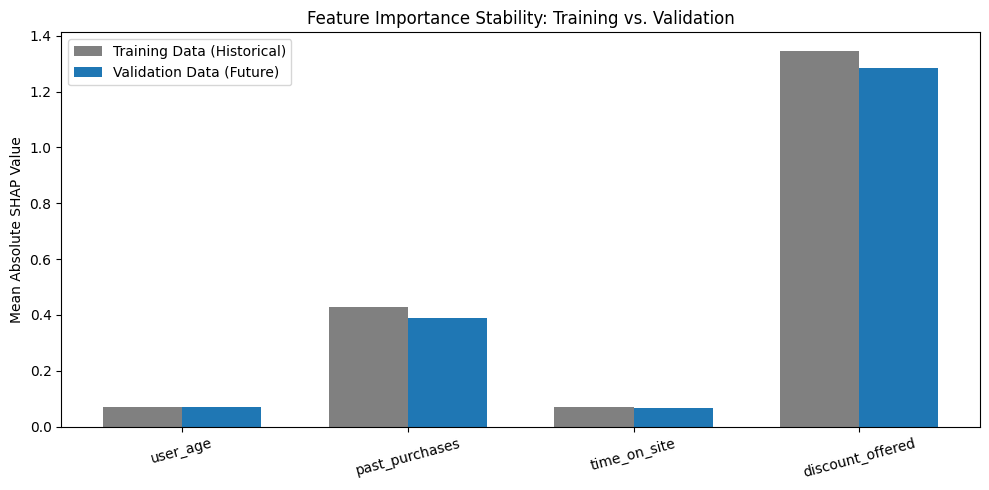

In [9]:
# ==========================================
# CELL 6: Test 2 - Generalization and Stability
# ==========================================
print("Running Test 2: Generalization and Feature Logic Stability...")

# Evaluate feature importance across historical (train) and future (validation) distributions
shap_train = explainer_cte.shap_values(X_train.sample(500, random_state=42))
shap_val = explainer_cte.shap_values(X_val.sample(500, random_state=42))

train_imp = np.abs(shap_train).mean(0)
val_imp = np.abs(shap_val).mean(0)

# Visualize the comparison to detect potential overfitting or concept drift
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(features))
width = 0.35

ax.bar(x_pos - width/2, train_imp, width, label='Training Data (Historical)', color='#808080')
ax.bar(x_pos + width/2, val_imp, width, label='Validation Data (Future)', color='#1f77b4')

ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=15)
ax.set_title("Feature Importance Stability: Training vs. Validation")
ax.set_ylabel("Mean Absolute SHAP Value")
ax.legend()
plt.tight_layout()
plt.show()

Running Test 3: Temporal Dynamics and Concept Drift Tracking...


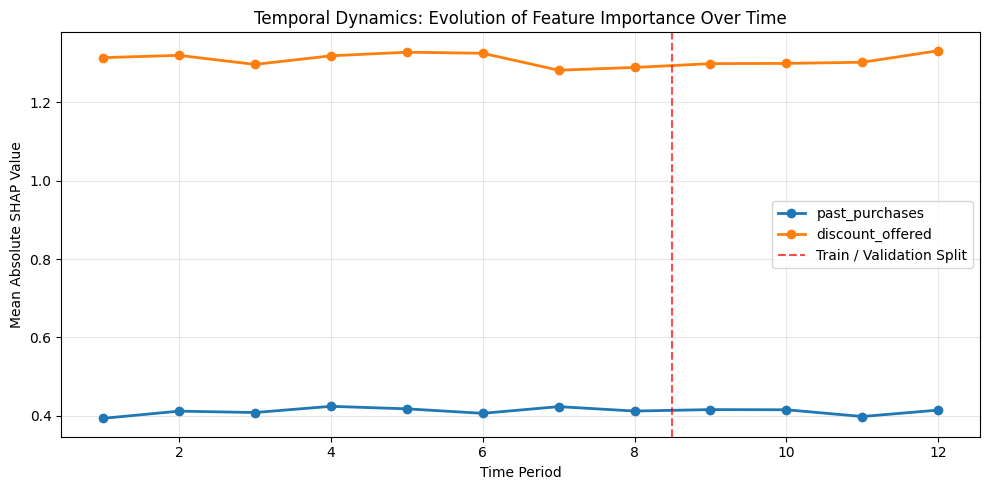

In [10]:
# ==========================================
# CELL 7: Test 3 - Temporal Dynamics and Concept Drift
# ==========================================
print("Running Test 3: Temporal Dynamics and Concept Drift Tracking...")

temporal_importances = []
periods_list = sorted(df['period'].unique())

# Evaluate SHAP values sequentially across distinct time periods
for p in periods_list:
    X_period = df[df['period'] == p][features]
    shap_p = explainer_cte.shap_values(X_period)
    temporal_importances.append(np.abs(shap_p).mean(0))

temporal_importances = np.array(temporal_importances)

plt.figure(figsize=(10, 5))
for i, col in enumerate(features):
    # Filter and plot only features with significant overall importance for visual clarity
    if np.mean(temporal_importances[:, i]) > 0.2:
        plt.plot(periods_list, temporal_importances[:, i], marker='o', linewidth=2, label=col)

plt.axvline(x=8.5, color='red', linestyle='--', alpha=0.7, label='Train / Validation Split')
plt.title("Temporal Dynamics: Evolution of Feature Importance Over Time")
plt.xlabel("Time Period")
plt.ylabel("Mean Absolute SHAP Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()